# Task 3 Report: MNIST Classification

## Task objective
Train and evaluate a neural-network classifier for handwritten digit recognition on the MNIST dataset, then explain both the data-analysis process and the model performance in a report-style workflow.

This notebook covers:

1. Reproducible setup and data loading
2. Normalization and data-loader construction
3. Train/test class-distribution inspection
4. Raw-vs-normalized representation visualization (UMAP and t-SNE)
5. CNN training configuration and learning behavior
6. Test-set evaluation using multiple metrics and confusion matrix


In [1]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import umap.umap_ as umap
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score,
    top_k_accuracy_score,
)
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Download ORIGINAL MNIST
train_dataset_raw = datasets.MNIST(root="./data", train=True, download=True)
test_dataset_raw = datasets.MNIST(root="./data", train=False, download=True)

print(f"Train samples: {len(train_dataset_raw)}")
print(f"Test samples: {len(test_dataset_raw)}")

sample_img, sample_label = train_dataset_raw[0]
print(f"Sample type: {type(sample_img)}")
print(f"Sample image size: {sample_img.size}, label: {sample_label}")


Train samples: 60000
Test samples: 10000
Sample type: <class 'PIL.Image.Image'>
Sample image size: (28, 28), label: 5


## 1) Data preprocessing strategy

MNIST images are grayscale (`28x28`) and are first converted to tensors, then standardized with dataset statistics.

- The notebook computes mean and standard deviation directly from the training split (`train_mean`, `train_std`).
- A transform pipeline applies:
  - `ToTensor()` to map pixel range from `[0, 255]` into `[0, 1]`.
  - `Normalize((mean,), (std,))` so optimization sees centered/scaled inputs.
- Separate `DataLoader`s are then built for train/test:
  - training uses `shuffle=True` for stochastic mini-batch learning,
  - test uses `shuffle=False` for deterministic evaluation.

Why this matters:

- Proper normalization improves optimization stability and usually accelerates convergence.
- Using training-only statistics avoids leaking information from the test set into training design.


In [2]:
train_mean = train_dataset_raw.data.float().mean() / 255.0
train_std = train_dataset_raw.data.float().std() / 255.0
print(f"Computed mean: {train_mean:.4f}, std: {train_std:.4f}")

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((train_mean.item(),), (train_std.item(),))
])
train_dataset = datasets.MNIST(root="./data", train=True, download=False, transform=preprocess)
test_dataset = datasets.MNIST(root="./data", train=False, download=False, transform=preprocess)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Computed mean: 0.1307, std: 0.3081
Train batches: 469
Test batches: 79


## 2) Dataset balance check (train and test)

Before training, we inspect class frequencies for digits `0-9` in both splits.

- The train split has near-uniform class coverage (roughly 5.4k-6.7k samples per class).
- The test split is also well balanced (roughly 0.89k-1.14k per class).

Why include this step:

- It verifies that strong performance is not caused by severe class skew.
- It helps interpret macro-averaged metrics later (precision/recall/F1 across all classes).


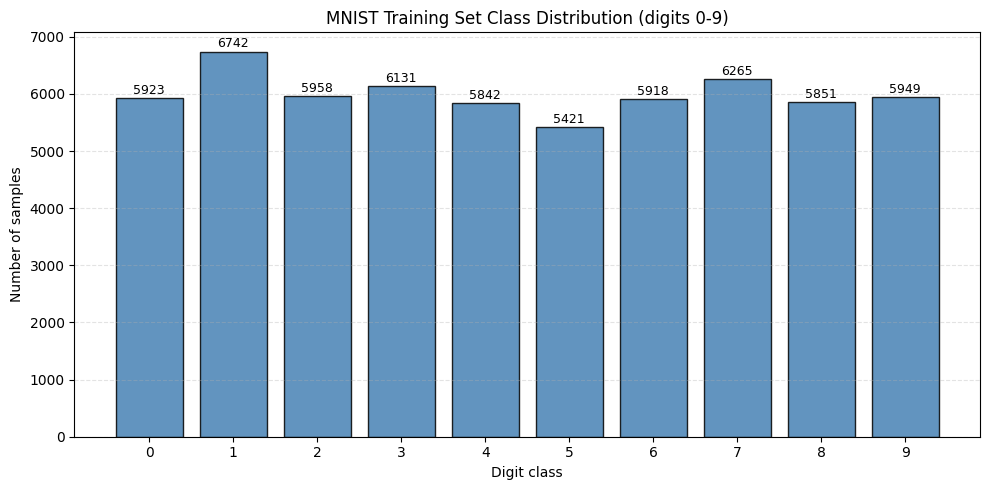

In [3]:
train_labels = train_dataset_raw.targets.numpy()
train_counts = np.bincount(train_labels, minlength=10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(np.arange(10), train_counts, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_title("MNIST Training Set Class Distribution (digits 0-9)")
ax.set_xlabel("Digit class")
ax.set_ylabel("Number of samples")
ax.set_xticks(np.arange(10))
for bar, count in zip(bars, train_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

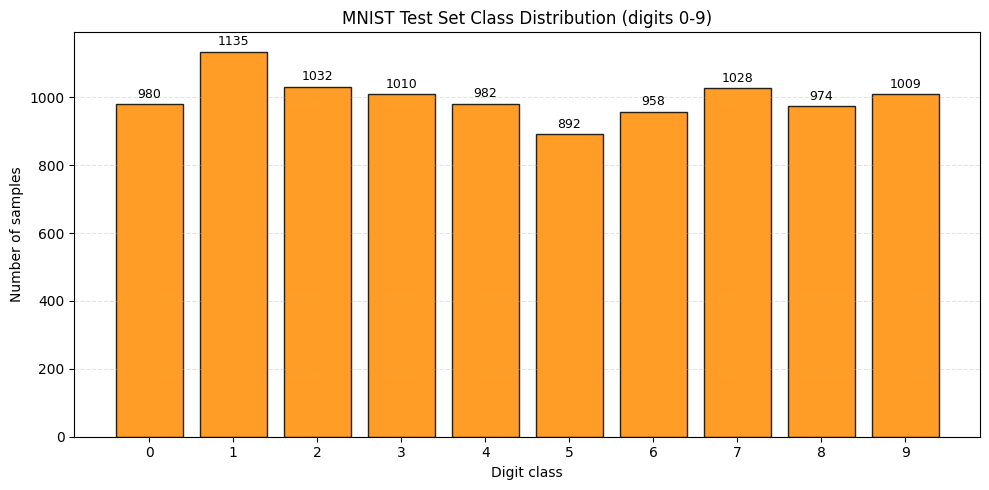

In [4]:
test_labels = test_dataset_raw.targets.numpy()
test_counts = np.bincount(test_labels, minlength=10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(np.arange(10), test_counts, color="darkorange", edgecolor="black", alpha=0.85)
ax.set_title("MNIST Test Set Class Distribution (digits 0-9)")
ax.set_xlabel("Digit class")
ax.set_ylabel("Number of samples")
ax.set_xticks(np.arange(10))
for bar, count in zip(bars, test_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## 3) Representation visualization: raw pixels vs normalized pixels

To understand how preprocessing changes data geometry, the notebook compares embeddings from the **same sampled images** under two input spaces:

- raw pixel vectors (`X_raw`),
- normalized vectors (`X_norm`).

Method details:

- A stratified sample (`3000` total) is drawn so each digit contributes equally.
- Two nonlinear manifold methods are applied:
  - **UMAP** for local/global neighborhood structure,
  - **t-SNE** for local-cluster separation.

Interpretation goal:

- Evaluate whether normalization improves class compactness and separation in 2D projections.
- Build intuition for why a nonlinear model (CNN) is suitable for this classification task.


In [5]:
X_raw = train_dataset_raw.data.numpy().reshape(len(train_dataset_raw), -1).astype(np.float32) / 255.0
y_raw = train_dataset_raw.targets.numpy()
X_norm = (X_raw - train_mean.item()) / train_std.item()

# Stratified sampling so each digit is equally represented
sample_size = 3000
rng = np.random.default_rng(SEED)
classes = np.unique(y_raw)
per_class = sample_size // len(classes)

sample_idx = []
for c in classes:
    cls_idx = np.where(y_raw == c)[0]
    sample_idx.extend(rng.choice(cls_idx, size=per_class, replace=False))

sample_idx = np.array(sample_idx)
X_raw_sample = X_raw[sample_idx]
X_norm_sample = X_norm[sample_idx]
y_sample = y_raw[sample_idx]

print(f"Embedding sample size: {len(X_raw_sample)}")
print("Comparing RAW vs NORMALIZED using the same sampled points.")


Embedding sample size: 3000
Comparing RAW vs NORMALIZED using the same sampled points.


In [6]:
def compute_umap_tsne(X, seed=SEED):
    """Return 2D UMAP and t-SNE embeddings for input matrix X."""
    umap_emb = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=seed,
    ).fit_transform(X)

    tsne_emb = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="random", # random or pca
        random_state=seed,
    ).fit_transform(X)

    return umap_emb, tsne_emb

print("Computing embeddings for RAW data...")
raw_umap, raw_tsne = compute_umap_tsne(X_raw_sample)

print("Computing embeddings for NORMALIZED data...")
norm_umap, norm_tsne = compute_umap_tsne(X_norm_sample)


Computing embeddings for RAW data...
Computing embeddings for NORMALIZED data...


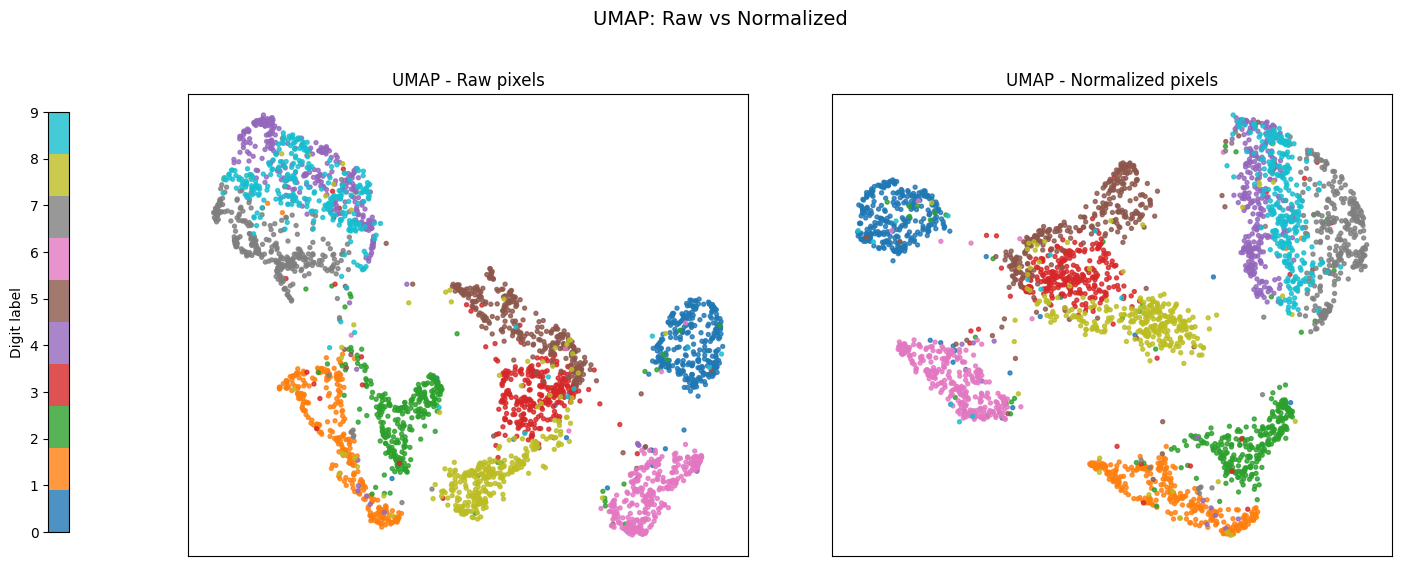

In [7]:
# UMAP
fig_umap, axes_umap = plt.subplots(1, 2, figsize=(14, 6))
umap_plots = [
    (raw_umap, "UMAP - Raw pixels", axes_umap[0]),
    (norm_umap, "UMAP - Normalized pixels", axes_umap[1]),
]
for emb, title, ax in umap_plots:
    sc_umap = ax.scatter(emb[:, 0], emb[:, 1], c=y_sample, cmap="tab10", s=8, alpha=0.8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig_umap.subplots_adjust(left=0.12, right=0.98, wspace=0.15)
cax_umap = fig_umap.add_axes([0.02, 0.15, 0.015, 0.7])
cbar_umap = fig_umap.colorbar(sc_umap, cax=cax_umap)
cbar_umap.set_label("Digit label")
cbar_umap.ax.yaxis.set_ticks_position("left")
cbar_umap.ax.yaxis.set_label_position("left")
fig_umap.suptitle("UMAP: Raw vs Normalized", y=1.02, fontsize=14)
plt.show()

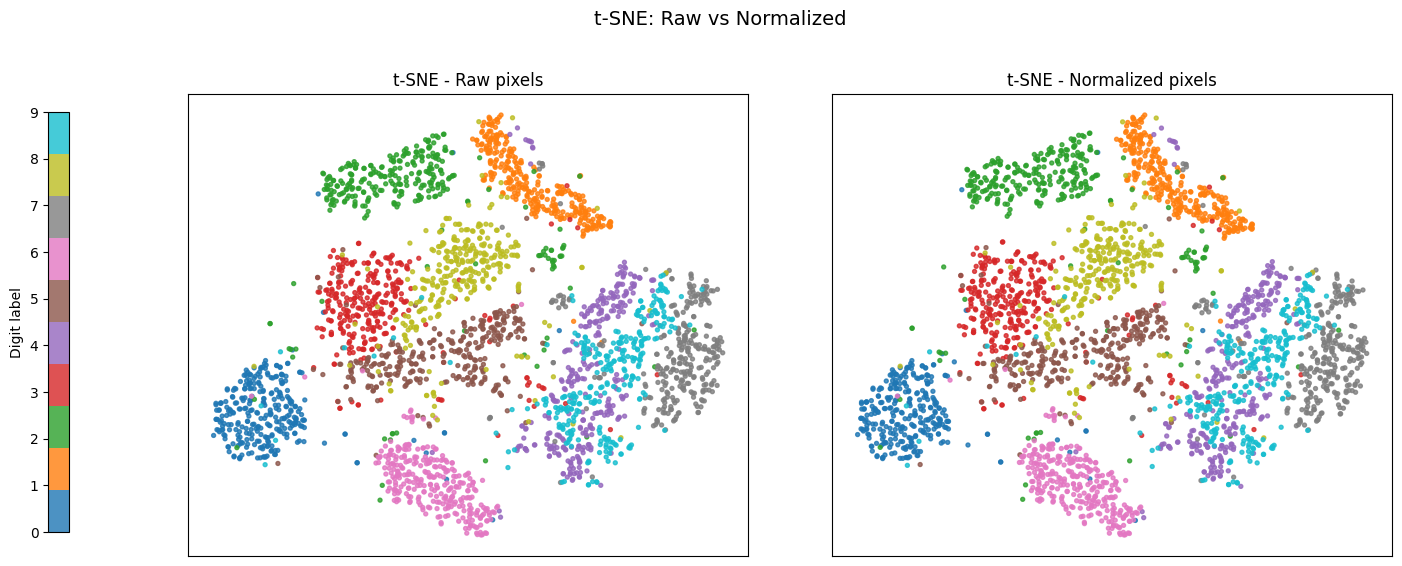

In [8]:
# t-SNE
fig_tsne, axes_tsne = plt.subplots(1, 2, figsize=(14, 6))
tsne_plots = [
    (raw_tsne, "t-SNE - Raw pixels", axes_tsne[0]),
    (norm_tsne, "t-SNE - Normalized pixels", axes_tsne[1]),
]
for emb, title, ax in tsne_plots:
    sc_tsne = ax.scatter(emb[:, 0], emb[:, 1], c=y_sample, cmap="tab10", s=8, alpha=0.8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig_tsne.subplots_adjust(left=0.12, right=0.98, wspace=0.15)
cax_tsne = fig_tsne.add_axes([0.02, 0.15, 0.015, 0.7])
cbar_tsne = fig_tsne.colorbar(sc_tsne, cax=cax_tsne)
cbar_tsne.set_label("Digit label")
cbar_tsne.ax.yaxis.set_ticks_position("left")
cbar_tsne.ax.yaxis.set_label_position("left")
fig_tsne.suptitle("t-SNE: Raw vs Normalized", y=1.02, fontsize=14)
plt.show()

## 4) Model selection and training setup

A compact CNN (`SimpleCNN`) is trained for MNIST classification.

Architecture summary:

- Feature extractor:
  - Conv(1->32, `3x3`) + ReLU + MaxPool
  - Conv(32->64, `3x3`) + ReLU + MaxPool
- Classifier:
  - Flatten -> Linear(`64*7*7 -> 128`) -> ReLU -> Dropout(0.2) -> Linear(128 -> 10)

Optimization configuration:

- Loss: `CrossEntropyLoss`
- Optimizer: `Adam(lr=1e-3)`
- Epochs: `5`
- Device: CUDA if available, otherwise CPU

Why this model is reasonable:

- Convolutions exploit spatial locality in handwritten digits.
- Pooling provides translation tolerance and parameter efficiency.
- The architecture is lightweight but strong for MNIST-scale tasks.


Using device: cuda
Epoch 01/5 | Train Loss: 0.1954 | Train Acc: 0.9394
Epoch 02/5 | Train Loss: 0.0551 | Train Acc: 0.9831
Epoch 03/5 | Train Loss: 0.0397 | Train Acc: 0.9880
Epoch 04/5 | Train Loss: 0.0315 | Train Acc: 0.9900
Epoch 05/5 | Train Loss: 0.0236 | Train Acc: 0.9924


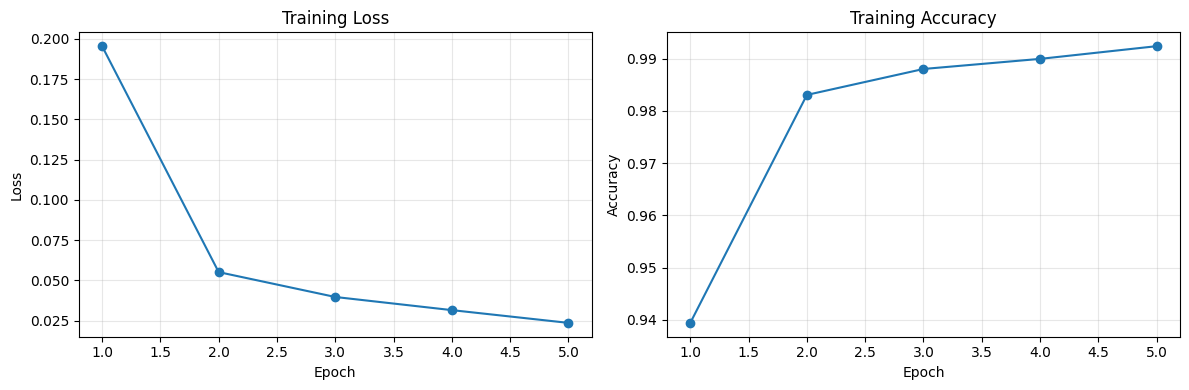

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
history = {"train_loss": [], "train_acc": []}

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)

    print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, num_epochs + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, num_epochs + 1), history["train_acc"], marker="o")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Test evaluation protocol

The model is evaluated on the full MNIST test set with probability-based and label-based metrics.

Reported metrics include:

- `test_loss` (cross-entropy),
- accuracy,
- macro and weighted precision/recall/F1,
- top-3 accuracy,
- multiclass log-loss,
- one-vs-rest macro ROC-AUC,
- full classification report,
- confusion matrix visualization.

This combination provides both high-level quality (accuracy/F1) and calibration/ranking signals (log-loss, ROC-AUC).


Test metrics:
- test_loss: 0.0253
- accuracy: 0.9916
- macro_precision: 0.9916
- macro_recall: 0.9914
- macro_f1: 0.9915
- weighted_precision: 0.9916
- weighted_recall: 0.9916
- weighted_f1: 0.9916
- top3_accuracy: 0.9996
- log_loss: 0.0253
- roc_auc_ovr_macro: 1.0000

Classification report:
              precision    recall  f1-score   support

           0     0.9829    0.9980    0.9904       980
           1     0.9965    0.9974    0.9969      1135
           2     0.9913    0.9932    0.9923      1032
           3     0.9892    0.9970    0.9931      1010
           4     0.9969    0.9939    0.9954       982
           5     0.9921    0.9809    0.9865       892
           6     0.9968    0.9885    0.9927       958
           7     0.9865    0.9922    0.9893      1028
           8     0.9938    0.9877    0.9907       974
           9     0.9900    0.9851    0.9876      1009

    accuracy                         0.9916     10000
   macro avg     0.9916    0.9914    0.9915     10000
wei

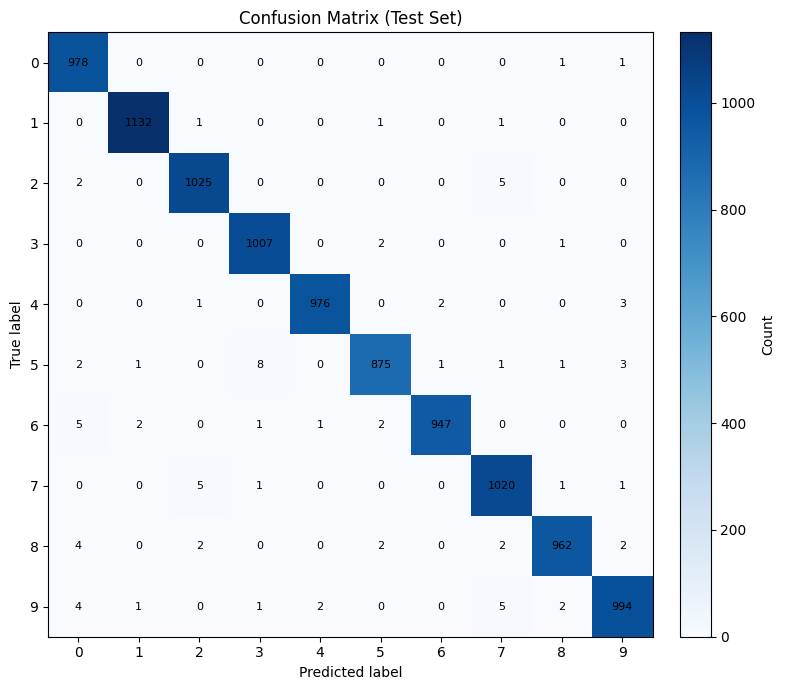

In [10]:
model.eval()
all_targets = []
all_preds = []
all_probs = []
test_loss_sum = 0.0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        test_loss_sum += loss.item() * labels.size(0)
        test_total += labels.size(0)

        all_targets.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

y_true = np.concatenate(all_targets)
y_pred = np.concatenate(all_preds)
y_prob = np.concatenate(all_probs)

test_loss = test_loss_sum / test_total
acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

metrics = {
    "test_loss": float(test_loss),
    "accuracy": float(acc),
    "macro_precision": float(precision_macro),
    "macro_recall": float(recall_macro),
    "macro_f1": float(f1_macro),
    "weighted_precision": float(precision_weighted),
    "weighted_recall": float(recall_weighted),
    "weighted_f1": float(f1_weighted),
    "top3_accuracy": float(top_k_accuracy_score(y_true, y_prob, k=3, labels=np.arange(10))),
    "log_loss": float(log_loss(y_true, y_prob, labels=np.arange(10))),
}

metrics["roc_auc_ovr_macro"] = float(
    roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
)

print("Test metrics:")
for name, value in metrics.items():
    print(f"- {name}: {value:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Count")
plt.tight_layout()
plt.show()

## 6) Result summary and interpretation

From the shown run in this notebook:

- Training improved consistently across 5 epochs (loss down, accuracy up to ~0.992).
- Test performance is very strong:
  - accuracy: **0.9916**,
  - macro F1: **0.9915**,
  - weighted F1: **0.9916**,
  - top-3 accuracy: **0.9996**,
  - log-loss: **0.0253**,
  - ROC-AUC (OvR macro): **~1.0000**.

Key interpretation:

- The CNN generalizes well on MNIST, with balanced precision/recall across classes.
- Minor residual errors are visible in the confusion matrix, but no severe class collapse appears.
- Overall, preprocessing + compact CNN + Adam forms an effective baseline for this task.
